<center>
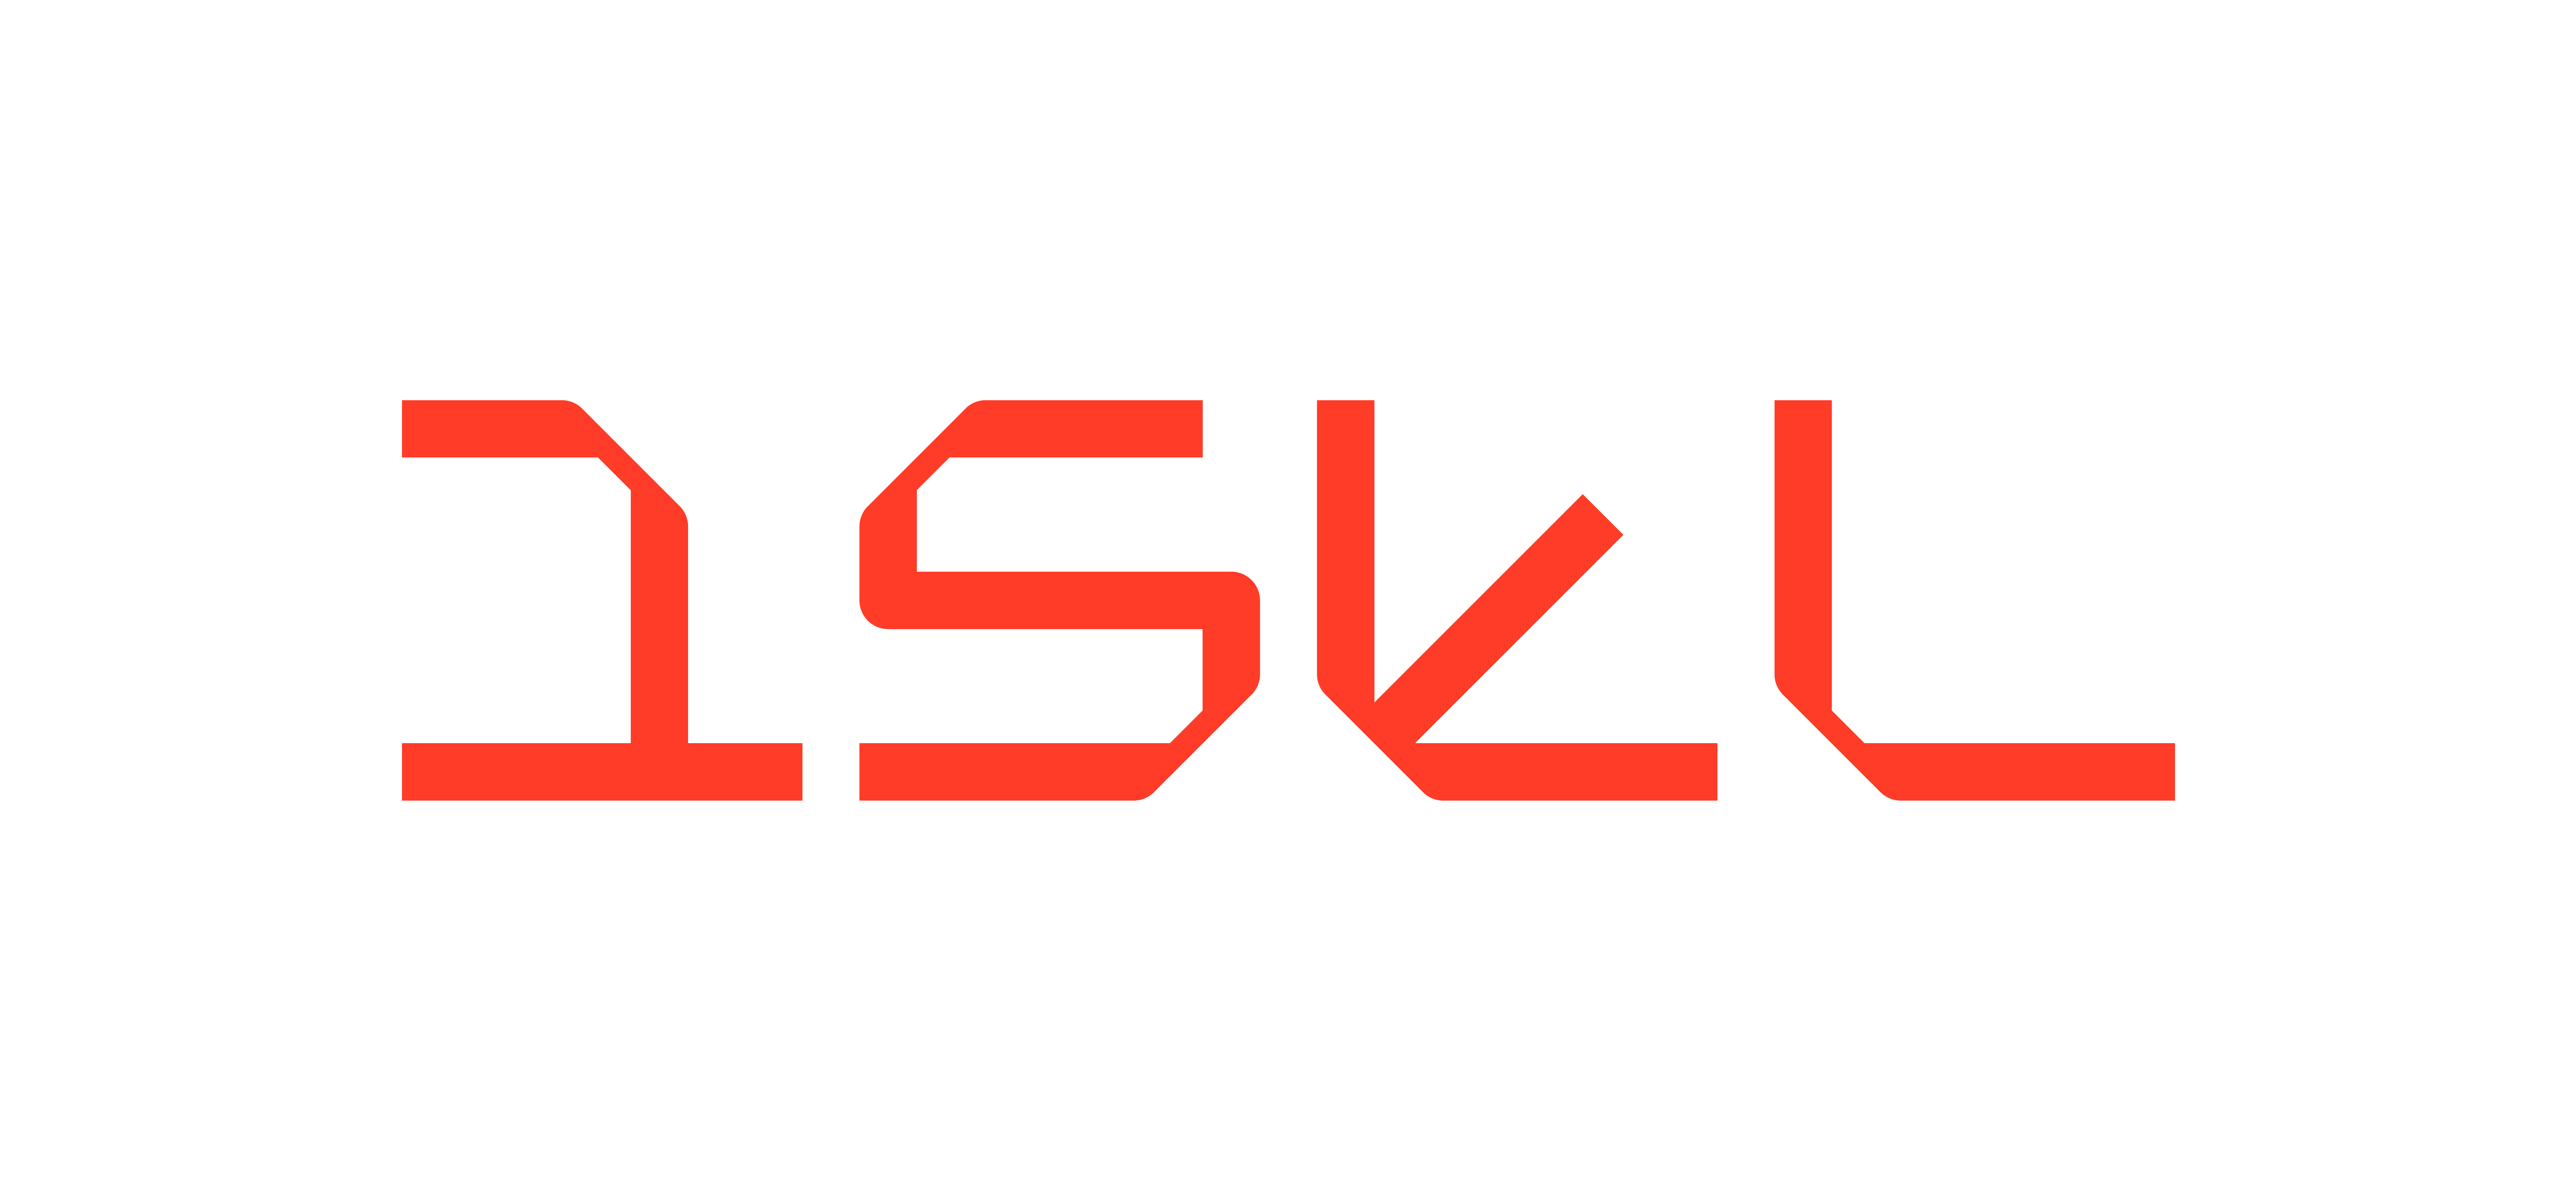
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

In [1]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
#from collections import Counter
from scipy.spatial import distance as dist
#from collections import OrderedDict
import time
import random
import ctypes
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.13.7)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
folder = "assets/media/"
folderXML = "assets/xml/"
frame_test = cv.imread(folder + "img_teste_4.png")

In [ ]:
# Som da bola
pygame.mixer.init()
pop_som = pygame.mixer.Sound(folder + "pop.mp3")

Frame capturado: (480, 640, 3)


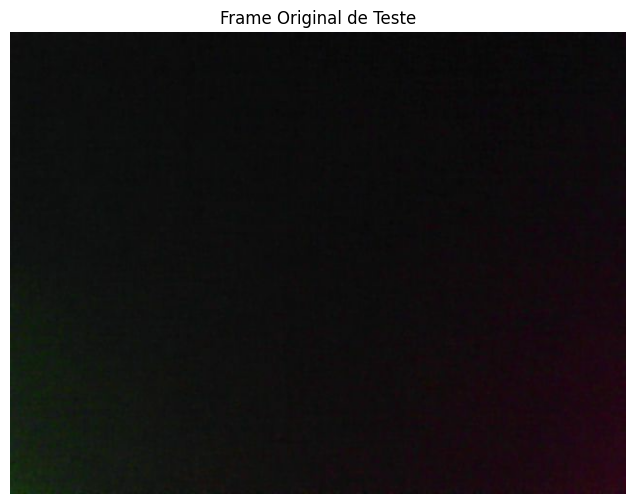

In [47]:
# Capturar um frame da webcam para experiência

cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

In [ ]:
class Config:
    # Parâmetros de Jogo
    GAME_DURATION = 10
    
    # Parâmetros de Visão
    MIN_CONTOUR_AREA = 2000
    
    # Ranges YCrCb para pele (Luminância, Vermelho-Diferença, Azul-Diferença)
    SKIN_YCRCB_LOWER = np.array([0, 133, 77], dtype=np.uint8)
    SKIN_YCRCB_UPPER = np.array([255, 173, 127], dtype=np.uint8)
    
    # Ranges HSV para pele (Tonalidade, Saturação, Valor)
    SKIN_HSV_LOWER = np.array([0, 20, 70], dtype=np.uint8)
    SKIN_HSV_UPPER = np.array([20, 255, 255], dtype=np.uint8)
    
    # Kernels Morfológicos
    KERNEL_ELLIPSE_5 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    KERNEL_ELLIPSE_15 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15, 15))

In [ ]:
class VirtualBall:
    def __init__(self, x, y, radius=30, color=(0, 255, 255), tipo="normal"):
        self.x = x
        self.y = y
        self.vx = random.randint(-5, 5)
        self.vy = random.randint(-5, 5)
        self.radius = radius
        self.color = color
        self.active = True
        self.tipo = tipo
        # adicao de um tipo diferente de VirtualBall, com dobro dos pontos
        if tipo == "normal":
            self.color = (0, 255, 255)
            self.points = 1
        elif tipo == "especial":
            self.color = (225, 73, 57)
            self.points = 2
        self.active = True

        # bolas especiais tem alguns segundos ate desaparecerem
        self.lifetime = random.randint(4,5)  if tipo == "especial" else None
        self.spawn_time = time.time()
        
    # animacao de rebentar
        self.popping = False
        self.pop_frame = 0
        self.max_pop_frames = 8

    def expired(self):
        if self.tipo == "especial":
            tempo = time.time() - self.spawn_time
            print(str(tempo) + " " + str(self.lifetime))
            if tempo >= self.lifetime :
                self.popping = True
                return True
        return False
        
    def start_pop(self):
        self.popping = True
        self.pop_frame = 0

    def draw_pop(self, frame):
        if not self.popping:
            return False
        self.active = False
        progresso = self.pop_frame / self.max_pop_frames

        # raio aumenta e transparencia diminui conforme frame
        pop_radius = int(self.radius * (1. + progresso * 0.8))
        opacity = max(0, 1.0 - progresso)

        frame_new = frame.copy()
        cv.circle(frame_new, (self.x, self.y), pop_radius, self.color, 2)
        
        cv.addWeighted(frame_new, opacity, frame, 1 - opacity, 0, frame)

        self.pop_frame += 1
        return self.pop_frame < self.max_pop_frames
        
    def update(self, width, height):
        if not self.active: return
        self.x += self.vx
        self.y += self.vy
        if self.x - self.radius < 0 or self.x + self.radius > width: self.vx *= -1
        if self.y - self.radius < 0 or self.y + self.radius > height: self.vy *= -1

    def draw(self, frame):
              
        if self.active and not self.popping:
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, self.color, -1)
            cv.circle(frame, (int(self.x), int(self.y)), self.radius, (0,0,0), 2)
        else:
            # Animacao de rebentar
            still_animating = self.draw_pop(frame)
            if not still_animating:
                self.popping = False

    def check_collision_with_point(self, point, collision_radius=60):
        if not self.active: return False
        px, py = point
        dist = np.sqrt((self.x - px)**2 + (self.y - py)**2)
        
        if dist < self.radius + collision_radius:
            self.popping = True
            return True
        return False

In [ ]:
class RegionDetector:
    def __init__(self):
        # Carregar Haar Cascade
        path = folderXML + 'haarcascade_frontalface_default.xml'
        self.face_cascade = cv.CascadeClassifier(path)
        if self.face_cascade.empty():
            self.face_cascade = cv.CascadeClassifier(cv.data.haarcascades + path)

    def get_contour_features(self, cnt, frame_height):
            """
            Cálculo dos contornos.
            """
            area = cv.contourArea(cnt)
            if area == 0: return None
            
            x, y, w, h = cv.boundingRect(cnt)
            M = cv.moments(cnt)
            cx = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
            cy = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

            perimeter = cv.arcLength(cnt, True)
            if perimeter == 0: return None
            
            epsilon = 0.01 * perimeter 
            approx = cv.approxPolyDP(cnt, epsilon, True)
            hull = cv.convexHull(approx, returnPoints=False)
            
            defects_count = 0
            fingertips = []
            topmost = tuple(cnt[cnt[:, :, 1].argmin()][0])
            fingertips.append(topmost)

            if len(hull) > 3 and len(approx) > 3:
                try:
                    defects = cv.convexityDefects(approx, hull)
                    if defects is not None:
                        # defects shape: (N, 1, 4) -> (N, 4)
                        d = defects[:, 0, :]
                        
                        # Extrair índices e profundidades
                        start_idx, end_idx, far_idx, depth_fix = d[:, 0], d[:, 1], d[:, 2], d[:, 3]
                        
                        # Filtrar por profundidade (Vetorizado)
                        depths = depth_fix / 256.0
                        min_depth = max(5, frame_height * 0.05)
                        mask_depth = depths > min_depth
                        
                        if np.any(mask_depth):
                            # Obter coordenadas (apenas dos pontos válidos)
                            pts_start = approx[start_idx[mask_depth]][:, 0] # shape (M, 2)
                            pts_end = approx[end_idx[mask_depth]][:, 0]
                            pts_far = approx[far_idx[mask_depth]][:, 0]
                            
                            # Cálculo vetorial de distâncias (Norma L2)
                            a = np.linalg.norm(pts_end - pts_start, axis=1)
                            b = np.linalg.norm(pts_far - pts_start, axis=1)
                            c = np.linalg.norm(pts_end - pts_far, axis=1)
                            
                            # Lei dos Cossenos (Vetorizada)
                            # np.clip para evitar erros numéricos fora de [-1, 1]
                            cos_angle = (b**2 + c**2 - a**2) / (2 * b * c + 1e-7)
                            angles = np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))
                            
                            # Filtro de Ângulo (< 100 graus)
                            mask_angle = angles <= 100
                            
                            defects_count = np.sum(mask_angle)
                            
                            # Adicionar pontas dos dedos válidos
                            if defects_count > 0:
                                # Stack starts e ends que passaram no filtro de ângulo
                                valid_starts = pts_start[mask_angle]
                                valid_ends = pts_end[mask_angle]
                                
                                # Adicionar à lista (convertendo para tuples para compatibilidade)
                                for pt in valid_starts: fingertips.append(tuple(pt))
                                for pt in valid_ends: fingertips.append(tuple(pt))
                                
                                # Remover duplicados próximos
                                fingertips = list(set(fingertips)) 
                except Exception as e:
                    pass

            return {
                'cnt': approx, 'area': area, 'defects': defects_count, 
                'fingertips': fingertips, 'bbox': (x, y, w, h), 'center': (cx, cy)
            }

    def detect(self, mask, frame):
        h, w = frame.shape[:2]
        regions = {'head': None, 'hands': [], 'feet': []}
        
        # Detetar Cara e Remover da Máscara
        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        faces = []
        if not self.face_cascade.empty():
            faces = self.face_cascade.detectMultiScale(gray, 1.1, 5)
        
        mask_body = mask.copy()
        
        if len(faces) > 0:
            # Maior cara
            fx, fy, fw, fh = max(faces, key=lambda r: r[2] * r[3])
            
            # Expandir caixa da cabeça (incluir orelhas/testa)
            infl_w = int(fw * 0.2)
            infl_h = int(fh * 0.4)
            nx = max(0, fx - infl_w)
            ny = max(0, fy - infl_h)
            nw = min(w, fx + fw + infl_w) - nx
            nh = min(h, fy + fh + int(fh*0.3)) - ny
            
            regions['head'] = {
                'center': (nx + nw//2, ny + nh//2),
                'bbox': (nx, ny, nw, nh)
            }
            # Apagar cabeça da máscara
            cv.rectangle(mask_body, (nx, ny), (nx+nw, ny+nh), 0, -1)
        
        # 2. Processar Resto do Corpo
        contours, _ = cv.findContours(mask_body, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
        
        for cnt in contours:
            if cv.contourArea(cnt) < Config.MIN_CONTOUR_AREA: continue
            
            feats = self.get_contour_features(cnt, h)
            if not feats: continue
            
            rel_y = feats['center'][1] / h
            
            if rel_y > 0.8:
                regions['feet'].append(feats)
            else:
                # Se não é pé nem cabeça (já removida), é mão
                # Validar se tem forma ou dedos
                if feats['defects'] > 0 or feats['area'] < (w*h)*0.15:
                    regions['hands'].append(feats)

        return regions

    def draw_debug(self, frame, regions):
        # Cabeça
        if regions['head']:
            x, y, w, h = regions['head']['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 255), 2)
            cv.putText(frame, "HEAD", (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,255), 2)
        # Mãos
        for r in regions['hands']:
            cv.drawContours(frame, [r['cnt']], -1, (0, 255, 0), 2)
            for ft in r['fingertips']: # Pontos de colisão
                cv.circle(frame, ft, 5, (0, 0, 255), -1)
        # Pés
        for r in regions['feet']:
            x, y, w, h = r['bbox']
            cv.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
        return frame

In [ ]:
class ImageProcessor:
    def __init__(self):
        self.backSub = cv.createBackgroundSubtractorMOG2(history=500, varThreshold=100, detectShadows=False)

    def get_foreground_mask(self, frame):
        """Detecta apenas o que se mexe (foreground)."""
        # Aplica a subtração
        fg_mask = self.backSub.apply(frame)
        
        # Limpeza morfológica para remover ruído da câmara
        kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
        fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN, kernel)
        fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_DILATE, kernel)
        
        return fg_mask

    def get_combined_mask(self, frame):
        """Combina Movimento + Pele para máxima robustez"""
        # 1. O que é que se mexe? (Ignora a parede creme estática)
        motion_mask = self.get_foreground_mask(frame)
        
        # 2. O que é que parece pele? (YCrCb + HSV)
        skin_mask = self.get_skin_mask(frame) # A tua função atual
        
        # Intersecção: Tem de se mexer e parecer pele
        final_mask = cv.bitwise_and(motion_mask, skin_mask)
        
        return final_mask

    @staticmethod
    def get_skin_mask(frame):
        """
        Segmentação Híbrida: YCrCb + HSV
        Remove o que não é pele com alta precisão.
        """
        # YCrCb (Luminância, Crominância)
        ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
        mask_ycrcb = cv.inRange(ycrcb, Config.SKIN_YCRCB_LOWER, Config.SKIN_YCRCB_UPPER)
        
        # HSV (Matiz, Saturação) - Ranges estritos para evitar amarelos
        hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
        mask_hsv = cv.inRange(hsv, Config.SKIN_HSV_LOWER, Config.SKIN_HSV_UPPER)
        
        # Combinar com AND (Interseção) -> Tem de ser pele em ambos os espaços
        mask_skin = cv.bitwise_and(mask_ycrcb, mask_hsv)
        
        # Limpeza Morfológica
        mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, Config.KERNEL_ELLIPSE_5, iterations=3)
        mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, Config.KERNEL_ELLIPSE_5, iterations=2)
        
        # Dilatar para consolidar o corpo
        mask_final = cv.dilate(mask_clean, Config.KERNEL_ELLIPSE_15, iterations=2)
        
        return mask_final

In [ ]:
class GameApp:
    def __init__(self):
        self.cap = cv.VideoCapture(0)
        
        # Configurar Janela
        try:
            user32 = ctypes.windll.user32
            user32.SetProcessDPIAware()
            w, h = user32.GetSystemMetrics(0), user32.GetSystemMetrics(1)
        except: w, h = 1280, 720
            
        cv.namedWindow("Game", cv.WINDOW_NORMAL)
        cv.resizeWindow("Game", w - 100, h - 100)
        
        self.width = int(self.cap.get(cv.CAP_PROP_FRAME_WIDTH))
        self.height = int(self.cap.get(cv.CAP_PROP_FRAME_HEIGHT))
        
        self.detector = RegionDetector()
        self.processor = ImageProcessor()
        self.prev_hand_centers = []

        self.state = "MENU" # MENU, GAME, GAMEOVER
        self.balls = []
        self.score = 0
        self.start_time = 0

    def draw_motion_vectors(self, frame, current_regions):
            """
            Calcula e desenha vetores de movimento usando NumPy (Broadcasting).
            """
            current_centers = [r['center'] for r in current_regions['hands']]
            
            # Só calculamos se houver dados em ambos os instantes
            if self.prev_hand_centers and current_centers:
                
                curr = np.array(current_centers)
                prev = np.array(self.prev_hand_centers)
                
                # Expandir dimensões para criar matriz de diferenças: (N, 1, 2) - (1, M, 2)
                # Resultado: Matriz (N, M, 2) contendo a diferença (dx, dy) de todos para todos
                diffs = curr[:, np.newaxis, :] - prev[np.newaxis, :, :]
                
                # Distância Euclidiana (Norma L2) ao longo do eixo das coordenadas
                dists = np.linalg.norm(diffs, axis=2)
                
                # índice do vizinho mais próximo para cada mão atual
                nearest_indices = np.argmin(dists, axis=1)
                
                # Extrair as distâncias mínimas correspondentes
                # advanced indexing: [0, 1, 2...], [idx0, idx1, idx2...]
                min_dists = dists[np.arange(len(dists)), nearest_indices]
                
                for i, dist in enumerate(min_dists):
                    if 2 < dist < 150:
                        # Ponto atual
                        pt_curr = tuple(curr[i])
                        # Ponto anterior correspondente
                        pt_prev = tuple(prev[nearest_indices[i]])
                        
                        # Desenhar Seta
                        cv.arrowedLine(frame, pt_prev, pt_curr, (0, 0, 255), 3, tipLength=0.3)

            # Atualizar histórico
            self.prev_hand_centers = current_centers
            
            return frame

    def start_game(self):
        self.state = "GAME"
        self.score = 0
        self.start_time = time.time()
        self.balls = [VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50)) for _ in range(5)]

    def run(self):
        while True:
            ret, frame = self.cap.read()
            if not ret: break
            frame = cv.flip(frame, 1)
            key = cv.waitKey(1)
            # Obter Máscara Pele
            mask = self.processor.get_skin_mask(frame)
            
            # Detetar e Classificar Regiões
            regions = self.detector.detect(mask, frame)
            
            # Desenhar Debug (Contornos)
            frame = self.detector.draw_debug(frame, regions)

            frame = self.draw_motion_vectors(frame, regions)

            # --- LÓGICA DE ESTADOS ---
            if self.state == "MENU":
                cv.putText(frame, "Pressione SPACE para comecar", (50, 100), cv.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
                cv.putText(frame, "Modo: Detecao Auto de Pele", (50, 150), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 1)
                
                # Mostrar máscara pequena no canto para debug
                thumb_mask = cv.resize(mask, (160, 120))
                thumb_mask = cv.cvtColor(thumb_mask, cv.COLOR_GRAY2BGR)
                frame[self.height-130:self.height-10, 10:170] = thumb_mask
                cv.putText(frame, "Mask Debug", (10, self.height-135), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

                if key == 32: self.start_game()
                elif key == ord('q'): break

            elif self.state == "GAME":
                remaining = Config.GAME_DURATION - int(time.time() - self.start_time)
                if remaining <= 0: self.state = "GAMEOVER"
                
                active_balls_count = 0
                balls_to_remove = []

                for ball in self.balls:
                    ball.update(self.width, self.height)
                    ball.draw(frame)
                    
                    if ball.active:
                        active_balls_count += 1
                        hit = False
                        
                        # Colisão
                        for hand in regions['hands']:
                            # Garante que 'fingertips' existe, senão usa lista vazia
                            fingertips = hand.get('fingertips', [])
                            points = [hand['center']] + fingertips
                            
                            for pt in points:
                                radius = 60 if pt == hand['center'] else 30
                                if ball.check_collision_with_point(pt, radius):
                                    pop_som.play()
                                    hit = True; break
                            if hit: break
                        
                        if hit: 
                            self.score += 1
                    
                    # Se expirou ou foi atingida, marcar para remover
                    if ball.expired() or (not ball.active):
                        balls_to_remove.append(ball)

                # Remover bolas fora do loop principal
                for ball in balls_to_remove:
                    if ball in self.balls:
                        self.balls.remove(ball)
                        tipo = random.choices(["normal", "especial"], weights=[0.8, 0.2])[0]
                        self.balls.append(VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50), tipo=tipo))

                # Se não houver bolas nenhumas, repor 5
                if len(self.balls) == 0:
                     for _ in range(5):
                         tipo = random.choices(["normal", "especial"], weights=[0.8, 0.2])[0]
                         self.balls.append(VirtualBall(random.randint(50, self.width-50), random.randint(50, self.height-50), tipo=tipo))

                # HUD
                cv.putText(frame, f"Score: {self.score}", (30, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                cv.putText(frame, f"Time: {remaining}", (self.width-150, 50), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)
                
            elif self.state == "GAMEOVER":
                cv.putText(frame, "GAME OVER", (self.width//2-120, self.height//2), cv.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 3)
                cv.putText(frame, f"Final Score: {self.score}", (self.width//2-120, self.height//2+60), cv.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
                cv.putText(frame, "Press R to Restart", (self.width//2-120, self.height//2+120), cv.FONT_HERSHEY_SIMPLEX, 0.8, (200, 200, 200), 2)
                
                if key == ord('r'): self.start_game()
                elif key == ord('q'): break

            cv.imshow("Game", frame)
            if key == ord('q'): break
        
        self.cap.release()
        cv.destroyAllWindows()

In [24]:
if __name__ == "__main__":
    app = GameApp()
    app.run()

### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>


In [11]:
# guardado para bibliografia
# Source - https://stackoverflow.com/a
# Posted by spacether, modified by community. See post 'Timeline' for change history
# Retrieved 2025-11-28, License - CC BY-SA 4.0

user32 = ctypes.windll.user32
user32.SetProcessDPIAware()
[screen_w, screen_h] = [user32.GetSystemMetrics(0), user32.GetSystemMetrics(1)]

print([screen_w, screen_h])

[1920, 1080]
